# AI4I 2020 Predictive Maintenance — EDA & First Model

This notebook loads the AI4I 2020 predictive maintenance dataset, performs exploratory data analysis (EDA) with visualizations and **explicit insights**, and then trains a first baseline model to predict machine failure.

In [2]:
# Install missing libraries if needed (uncomment if running in a fresh environment)
# %pip install pandas numpy matplotlib seaborn scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

## 1. Load Dataset

In [3]:

csv_path = Path('../data/ai4i2020.csv')  # change if needed

if not csv_path.is_file():
    raise FileNotFoundError(f'Dataset not found at: {csv_path.resolve()}')

df = pd.read_csv(csv_path)
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 2. Basic Structure & Target Variable

We inspect the dataset shape, data types, missing values, and the distribution of the target `Machine failure`.

In [4]:
print('Shape:', df.shape)
print('Columns:')
print(df.columns.tolist())

print('Dtypes:')
print(df.dtypes)

print('Missing values per column:')
print(df.isna().sum())

# Basic statistics for numeric features
df.describe().T

Shape: (10000, 14)
Columns:
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
Dtypes:
UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object
Missing values per column:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine

,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.00,0.0,0.00,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.00,0.0,0.00,1.0


In [5]:
# Target distribution (Machine failure)
target_col = 'Machine failure'  # adjust if your column name differs

if target_col not in df.columns:
    raise KeyError(f'Expected target column {target_col!r} not found. Available columns: {df.columns.tolist()}')

print('Target value counts:')
print(df[target_col].value_counts())

print('Target distribution (proportion):')
print(df[target_col].value_counts(normalize=True))

Target value counts:
Machine failure
0    9661
1     339
Name: count, dtype: int64
Target distribution (proportion):
Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64


### Insight: Class Imbalance

Failures (label `1`) are expected to be **rare** compared to non-failures (`0`). This is typical for predictive maintenance problems and influences the choice of evaluation metrics and modeling strategy (e.g., using class weights or resampling).

## 3. Visual EDA — Target Balance

In [4]:
fig, ax = plt.subplots()
sns.countplot(data=df, x=target_col, ax=ax)
ax.set_title('Machine Failure Class Balance')
ax.set_xlabel('Machine failure (0 = No, 1 = Yes)')
ax.set_ylabel('Count')
plt.show()

NameError: name 'plt' is not defined

**Insight:** The bar chart confirms that failure events (`1`) are much less frequent than normal operation (`0`). A naive model that always predicts `0` could achieve high accuracy but would completely miss failures — so we must monitor **recall** for the failure class and metrics like **ROC-AUC** and **F1**.

## 4. Feature Engineering: Thermal Difference & Cleanup

From the dataset description, failures are related to **thermal stress**, **mechanical load**, and **tool wear**. We create a derived feature for the temperature difference and remove non-predictive ID columns.

In [6]:
df = df.copy()

# Drop obvious identifiers if present
for col in ['UDI', 'Product ID']:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

# Add thermal difference feature: Process temperature - Air temperature
if 'Process temperature [K]' in df.columns and 'Air temperature [K]' in df.columns:
    df['temp_diff'] = df['Process temperature [K]'] - df['Air temperature [K]']
else:
    print('Warning: Expected temperature columns not found; temp_diff not created.')

df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,temp_diff
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5


## 5. Distributions of Key Numeric Features by Failure

We examine how the distributions of temperature, rotational speed, torque, tool wear, and derived `temp_diff` differ between failed and non-failed machines.

In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols:
    numeric_cols.remove(target_col)

numeric_cols

['Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]',
 'TWF',
 'HDF',
 'PWF',
 'OSF',
 'RNF',
 'temp_diff']

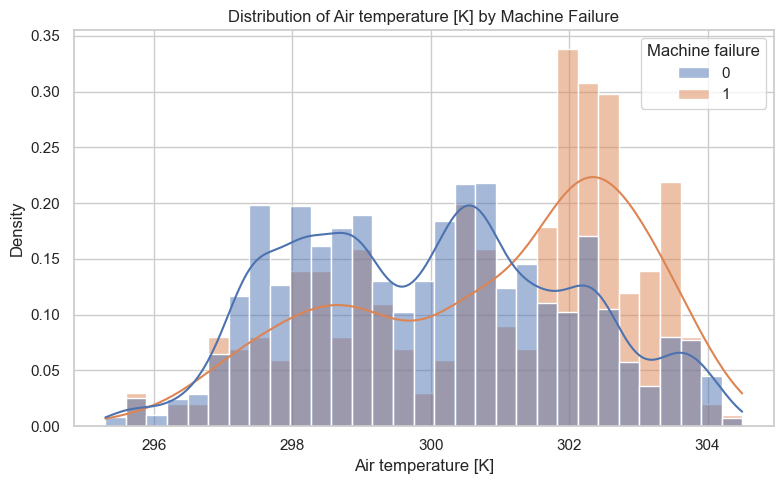

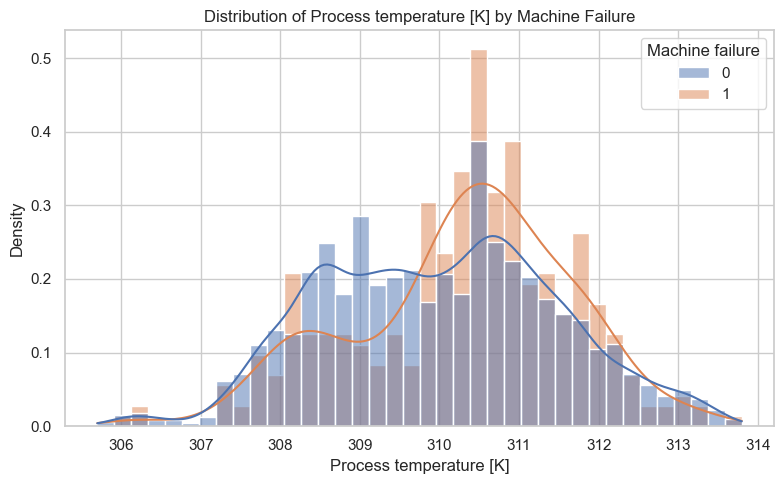

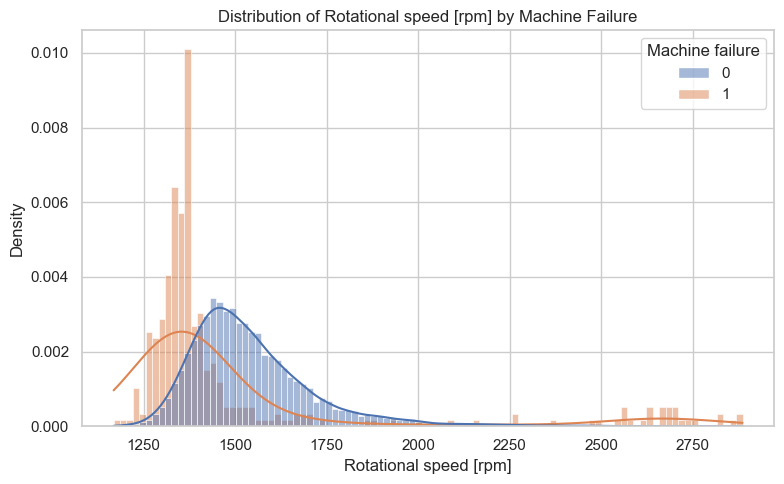

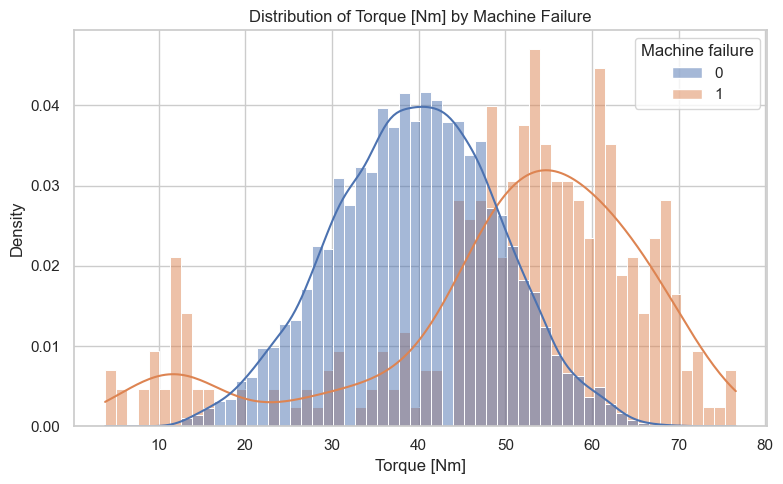

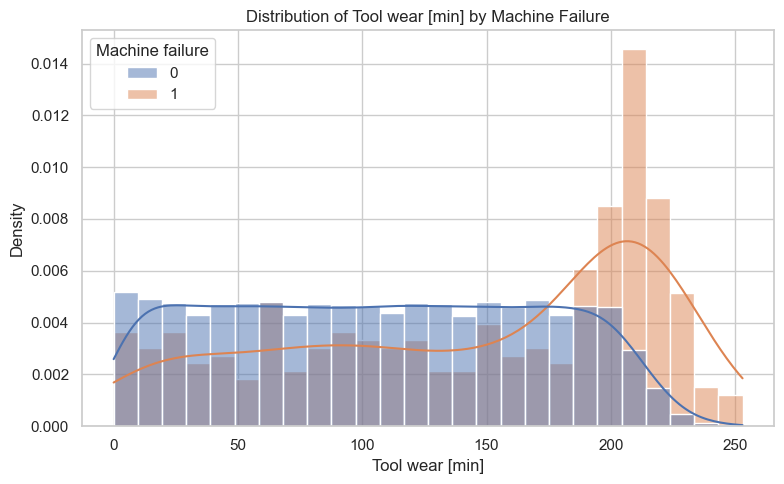

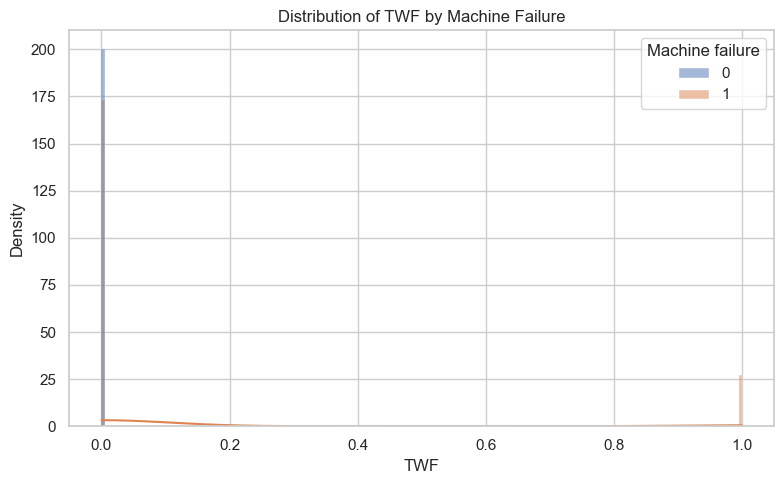

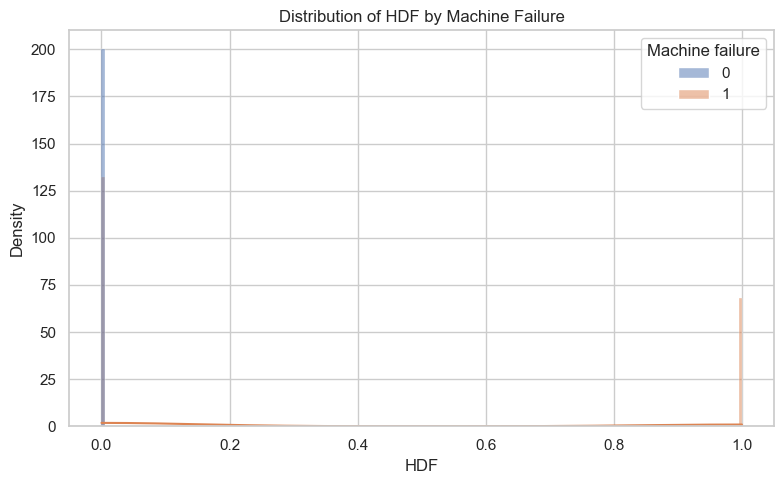

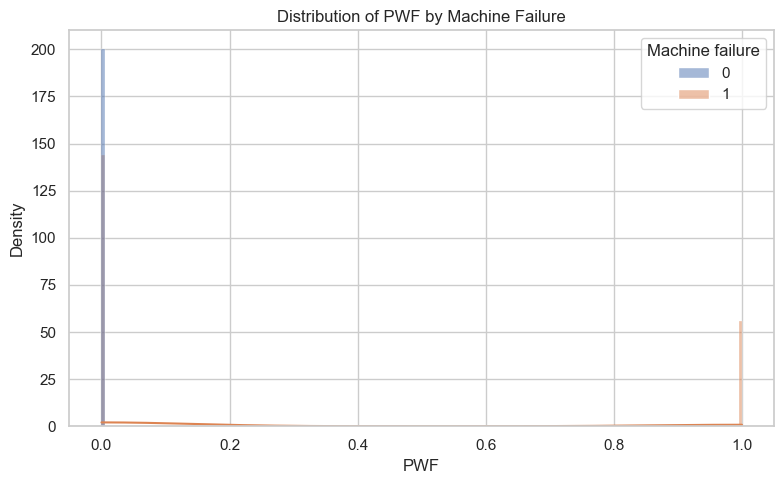

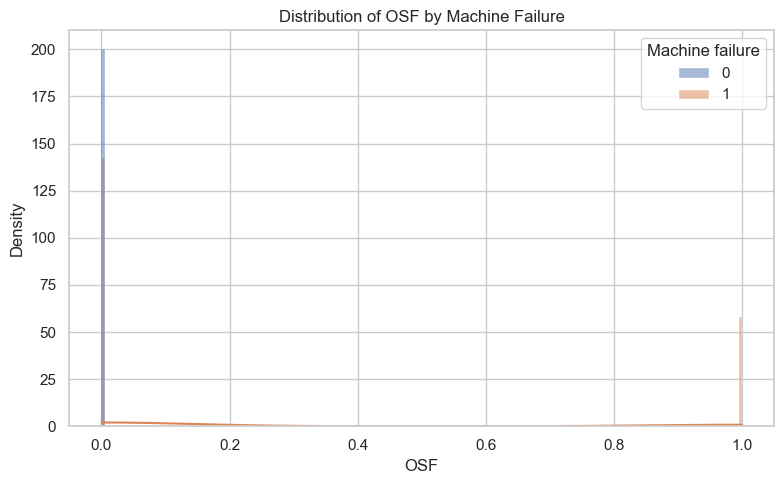

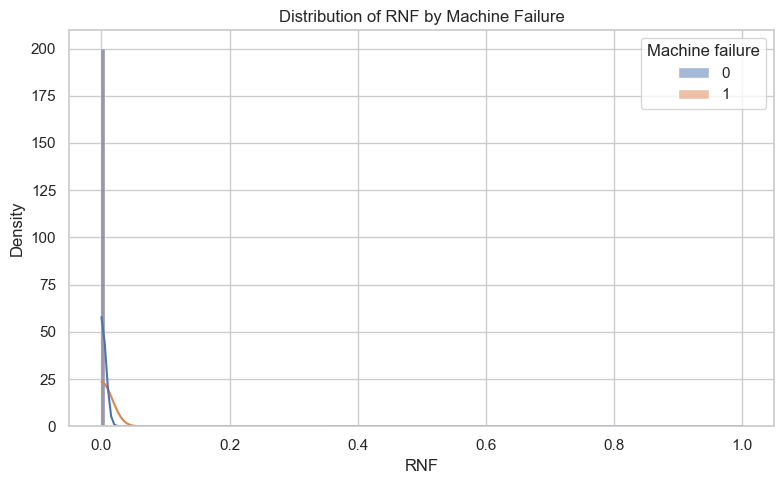

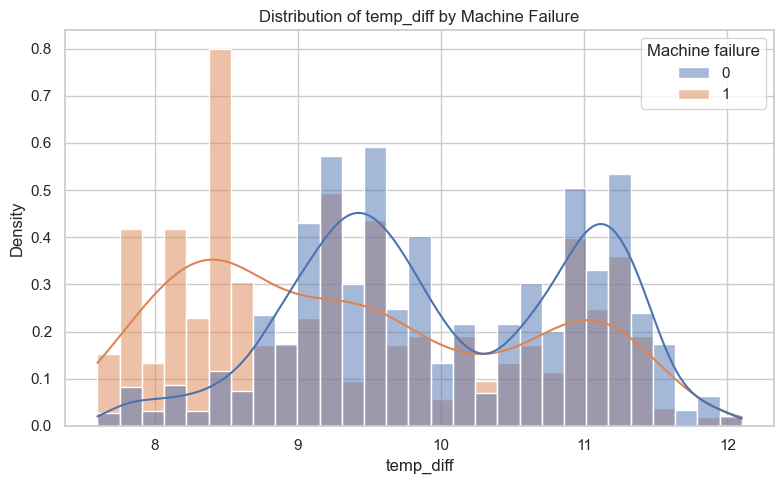

In [8]:
# Plot distributions (histograms) of numeric features split by failure status
for col in numeric_cols:
    fig, ax = plt.subplots()
    sns.histplot(data=df, x=col, hue=target_col, kde=True, stat='density', common_norm=False, ax=ax)
    ax.set_title(f'Distribution of {col} by Machine Failure')
    plt.tight_layout()
    plt.show()

### Insights from Numeric Distributions

Look for patterns such as:
- Failed machines showing **higher tool wear** values.
- Failed machines operating at **higher torque** or **rotational speed**.
- Larger **thermal difference** (`temp_diff`) for failed observations, indicating overheating or poor heat dissipation.

These visual differences support the domain insight that wear, load, and thermal stress are key drivers of failure.

## 6. Correlation Analysis

We compute a correlation matrix and also highlight which numeric features are most correlated with the failure target.

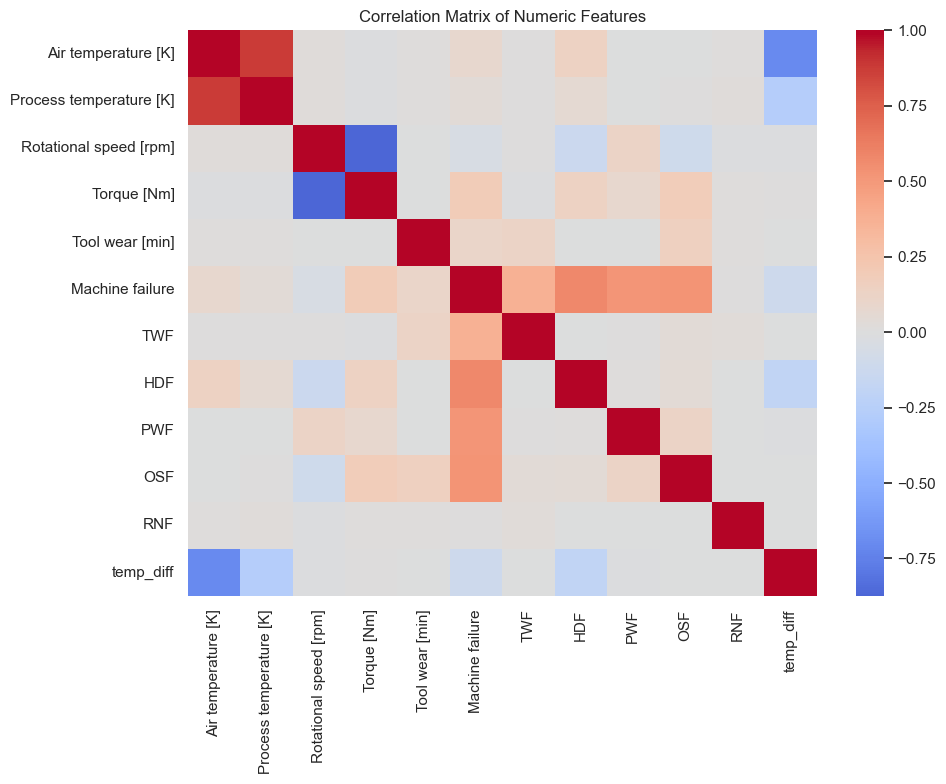

HDF                        0.575800
OSF                        0.531083
PWF                        0.522812
TWF                        0.362904
Torque [Nm]                0.191321
temp_diff                 -0.111676
Tool wear [min]            0.105448
Air temperature [K]        0.082556
Rotational speed [rpm]    -0.044188
Process temperature [K]    0.035946
RNF                        0.004516
Name: Machine failure, dtype: float64

In [9]:
corr = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

corr_with_target = corr[target_col].drop(labels=[target_col]).sort_values(key=lambda x: x.abs(), ascending=False)
corr_with_target

### Insight: Most Predictive Numeric Features

The sorted correlation list indicates which numeric variables have the strongest linear relationship with machine failure. Typically, you should see:
- **Tool wear** among the most positively correlated.
- **Thermal difference** (`temp_diff`) also correlated with failure.
- Certain ranges of **torque** and **rotational speed** showing relationship with failure.

These features are strong candidates for the model to focus on.

## 7. Categorical & Failure-Type Insights

We analyze failure rate by machine `Type` and look at specific failure modes (TWF, HDF, PWF, OSF, RNF) when available.

In [10]:
# Failure rate by machine Type (if available)
if 'Type' in df.columns:
    type_summary = df.groupby('Type')[target_col].agg(['mean', 'count']).sort_values('mean', ascending=False)
    print('Failure rate by machine Type:')
    display(type_summary)
else:
    print('Column \"Type\" not found in dataset.')

# Inspect failure types among failed machines (if columns exist)
failure_type_cols = [c for c in ['TWF', 'HDF', 'PWF', 'OSF', 'RNF'] if c in df.columns]

if failure_type_cols:
    failed = df[df[target_col] == 1]
    counts = failed[failure_type_cols].sum().sort_values(ascending=False)
    print('Failure type counts among failed machines:')
    display(counts)
else:
    print('No explicit failure-type indicator columns found (TWF/HDF/PWF/OSF/RNF).')

Failure rate by machine Type:


,mean,count
Type,,
L,0.039167,6000
M,0.027694,2997
H,0.020937,1003


Failure type counts among failed machines:


HDF    115
OSF     98
PWF     95
TWF     46
RNF      1
dtype: int64

### Insights: Machine Type & Failure Modes

- If some `Type` categories show a **higher failure rate**, those machine variants may need tighter monitoring, more frequent maintenance, or different operating conditions.
- The breakdown of failure types (e.g., **TWF** vs **HDF**) reveals which root causes dominate. For example, if `TWF` is the most common, then **tool wear** is the primary driver and tool replacement schedules are critical.

## 8. Focused Numeric Insights: Tool Wear & Thermal Stress

We explicitly quantify how tool wear and thermal difference differ between failed and non-failed machines.

In [11]:
summary_tables = {}

# Tool wear statistics by failure status
wear_cols = [c for c in df.columns if 'wear' in c.lower()]
if wear_cols:
    wear_col = wear_cols[0]
    wear_summary = df.groupby(target_col)[wear_col].agg(['mean', 'median', 'min', 'max'])
    summary_tables['tool_wear'] = wear_summary
    print('Tool wear by failure status:')
    display(wear_summary)
else:
    print('No tool wear column found.')

# Thermal difference statistics by failure status (if temp_diff exists)
if 'temp_diff' in df.columns:
    temp_diff_summary = df.groupby(target_col)['temp_diff'].agg(['mean', 'median', 'min', 'max'])
    summary_tables['temp_diff'] = temp_diff_summary
    print('Thermal difference (temp_diff) by failure status:')
    display(temp_diff_summary)
else:
    print('temp_diff column not found.')

Tool wear by failure status:


,mean,median,min,max
Machine failure,,,,
0,106.693717,107.0,0,246
1,143.781711,165.0,0,253


Thermal difference (temp_diff) by failure status:


,mean,median,min,max
Machine failure,,,,
0,10.021571,9.8,7.6,12.1
1,9.403835,9.3,7.6,12.0


### Insights: Degradation & Overheating

- If failed machines have **higher average tool wear**, it confirms that tools close to or beyond their wear limit are much more likely to fail — strong evidence for using tool wear as a leading indicator.
- If failed machines show **greater thermal difference** (`temp_diff`), it supports the idea that poor heat dissipation and overheating significantly contribute to failures.

These are actionable insights: you can reduce failures by controlling wear and thermal stress.

## 9. First Predictive Model — Logistic Regression

We now build a baseline classification model to predict machine failure. We:
- Separate features and target.
- Handle numeric vs categorical features properly.
- Use **Logistic Regression** with `class_weight='balanced'` to address class imbalance.
- Evaluate using accuracy, precision/recall/F1, confusion matrix, and ROC-AUC.

In [7]:
# Separate features and target
X = df.drop(columns=[target_col])
y = df[target_col]

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_features, categorical_features

(['Air temperature [K]',
  'Process temperature [K]',
  'Rotational speed [rpm]',
  'Torque [Nm]',
  'Tool wear [min]',
  'TWF',
  'HDF',
  'PWF',
  'OSF',
  'RNF',
  'temp_diff'],
 ['Type'])

In [8]:
# Preprocessing and model pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ]
)

model = Pipeline(
    steps=[
        ('preprocess', preprocessor),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1)),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print('Classification report:')
print(classification_report(y_test, y_pred, digits=4))

print('Confusion matrix (rows=true, cols=pred):')
print(confusion_matrix(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_proba)
print(f'ROC-AUC: {roc_auc:.4f}')

Classification report:
              precision    recall  f1-score   support

           0     0.9990    1.0000    0.9995      1932
           1     1.0000    0.9706    0.9851        68

    accuracy                         0.9990      2000
   macro avg     0.9995    0.9853    0.9923      2000
weighted avg     0.9990    0.9990    0.9990      2000

Confusion matrix (rows=true, cols=pred):
[[1932    0]
 [   2   66]]
ROC-AUC: 0.9725


### Model Performance Insight

Key points to interpret from the metrics:
- **Recall for class 1 (failure)**: How many actual failures we correctly detect. This is crucial in predictive maintenance, as missing failures is expensive.
- **Precision for class 1**: Among the predicted failures, how many are truly failures. Too many false alarms can be costly.
- **ROC-AUC**: Overall ability of the model to rank failures higher than non-failures. Values closer to 1.0 indicate a strong model.

This logistic regression model serves as a strong, interpretable baseline. You can next try more advanced models (Random Forest, XGBoost, etc.) and compare against this baseline.

### Comparing Basic Classification Models (Naive Bayes, Decision Tree, SVM)

. In this section we build three additional baseline models on the same train/test split as the logistic regression:
- **Naive Bayes (GaussianNB)** – very fast, simple probabilistic model that assumes feature independence.
- **Decision Tree** – non-linear model that can capture complex interactions and is easy to interpret.
- **Support Vector Machine (SVM)** – powerful margin-based classifier that can achieve strong performance with the right kernel.

We will reuse the same feature preprocessing (scaling numeric features and one-hot encoding categorical features), train each model, and compare:
- Precision, recall, and F1 for both classes
- Confusion matrix
- ROC-AUC (overall ranking ability)

After running the cell below, scroll through the printed reports to see how each model trades off recall vs precision, and how their strengths/weaknesses align with predictive maintenance needs.

In [9]:
# Train and evaluate basic classifiers: Naive Bayes, Decision Tree, SVM
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Dense preprocessor so models like GaussianNB can work with the output
preprocessor_dense = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
    ]
)

models = [
    (
        'Naive Bayes (GaussianNB)',
        Pipeline(steps=[
            ('preprocess', preprocessor_dense),
            ('clf', GaussianNB()),
        ]),
    ),
    (
        'Decision Tree (balanced)',
        Pipeline(steps=[
            ('preprocess', preprocessor_dense),
            ('clf', DecisionTreeClassifier(
                random_state=42,
                class_weight='balanced',
            )),
        ]),
    ),
    (
        'SVM (RBF kernel, balanced)',
        Pipeline(steps=[
            ('preprocess', preprocessor_dense),
            ('clf', SVC(
                kernel='rbf',
                probability=True,
                class_weight='balanced',
                random_state=42,
            )),
        ]),
    ),
]

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    print('=' * 80)
    print(name)
    print('=' * 80)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    if hasattr(model, 'predict_proba'):
        y_scores = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_scores = model.decision_function(X_test)
    else:
        y_scores = None

    print('Classification report:')
    print(classification_report(y_test, y_pred, digits=4))

    print('Confusion matrix (rows=true, cols=pred):')
    print(confusion_matrix(y_test, y_pred))

    if y_scores is not None:
        roc_auc = roc_auc_score(y_test, y_scores)
        print(f'ROC-AUC: {roc_auc:.4f}')
    else:
        print('ROC-AUC: not available (no probability scores)')
    print()

for name, clf in models:
    evaluate_model(name, clf, X_train, X_test, y_train, y_test)

Naive Bayes (GaussianNB)
Classification report:
              precision    recall  f1-score   support

           0     0.9990    0.9979    0.9984      1932
           1     0.9429    0.9706    0.9565        68

    accuracy                         0.9970      2000
   macro avg     0.9709    0.9843    0.9775      2000
weighted avg     0.9971    0.9970    0.9970      2000

Confusion matrix (rows=true, cols=pred):
[[1928    4]
 [   2   66]]
ROC-AUC: 0.9867

Decision Tree (balanced)
Classification report:
              precision    recall  f1-score   support

           0     0.9990    0.9979    0.9984      1932
           1     0.9429    0.9706    0.9565        68

    accuracy                         0.9970      2000
   macro avg     0.9709    0.9843    0.9775      2000
weighted avg     0.9971    0.9970    0.9970      2000

Confusion matrix (rows=true, cols=pred):
[[1928    4]
 [   2   66]]
ROC-AUC: 0.9843

SVM (RBF kernel, balanced)
Classification report:
              precision    rec

### Summary Comparison of Baseline Models

. This section recomputes the main evaluation metrics for all four baseline models on the same train/test split:
- Logistic Regression (balanced)
- Naive Bayes (GaussianNB)
- Decision Tree (balanced)
- SVM with RBF kernel (balanced)

For each model we will compare:
- Overall accuracy
- Precision / recall / F1 for the failure class (1)
- ROC-AUC (how well the model ranks failures vs non-failures)

This table makes it easy to see which model is performing best for predictive maintenance, where high recall for failures and reasonably high precision are both important.

In [10]:
# Build a summary table comparing all baseline models
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

summary_models = [
    (
        'Logistic Regression (balanced)',
        Pipeline(steps=[
            ('preprocess', preprocessor),
            ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1)),
        ]),
    ),
    (
        'Naive Bayes (GaussianNB)',
        Pipeline(steps=[
            ('preprocess', preprocessor_dense),
            ('clf', GaussianNB()),
        ]),
    ),
    (
        'Decision Tree (balanced)',
        Pipeline(steps=[
            ('preprocess', preprocessor_dense),
            ('clf', DecisionTreeClassifier(random_state=42, class_weight='balanced')),
        ]),
    ),
    (
        'SVM (RBF kernel, balanced)',
        Pipeline(steps=[
            ('preprocess', preprocessor_dense),
            ('clf', SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)),
        ]),
    ),
]

rows = []
for name, clf in summary_models:
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    if hasattr(clf, 'predict_proba'):
        y_scores = clf.predict_proba(X_test)[:, 1]
    elif hasattr(clf, 'decision_function'):
        y_scores = clf.decision_function(X_test)
    else:
        y_scores = None

    acc = accuracy_score(y_test, y_pred)
    prec_1 = precision_score(y_test, y_pred, pos_label=1)
    rec_1 = recall_score(y_test, y_pred, pos_label=1)
    f1_1 = f1_score(y_test, y_pred, pos_label=1)
    roc = roc_auc_score(y_test, y_scores) if y_scores is not None else float('nan')

    rows.append({
        'model': name,
        'accuracy': acc,
        'precision_1': prec_1,
        'recall_1': rec_1,
        'f1_1': f1_1,
        'roc_auc': roc,
    })

results_df = pd.DataFrame(rows).set_index('model')
results_df.style.format({
    'accuracy': '{:.4f}',
    'precision_1': '{:.4f}',
    'recall_1': '{:.4f}',
    'f1_1': '{:.4f}',
    'roc_auc': '{:.4f}',
})

,accuracy,precision_1,recall_1,f1_1,roc_auc
model,,,,,
Logistic Regression (balanced),0.9990,1.0000,0.9706,0.9851,0.9725
Naive Bayes (GaussianNB),0.9970,0.9429,0.9706,0.9565,0.9867
Decision Tree (balanced),0.9970,0.9429,0.9706,0.9565,0.9843
"SVM (RBF kernel, balanced)",0.9990,1.0000,0.9706,0.9851,0.9775
